# Importing Dataset and Model

In [1]:
import kagglehub
abhikjha_imdb_wiki_faces_dataset_path = kagglehub.dataset_download('abhikjha/imdb-wiki-faces-dataset')

print('Data source import complete.')

100%|██████████| 5.92G/5.92G [01:02<00:00, 102MB/s] 

Extracting files...


Data source import complete.


In [2]:
!cp -r /root/.cache/kagglehub/datasets/abhikjha/imdb-wiki-faces-dataset /content/


In [3]:
import scipy.io
import numpy as np
import os
import random
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
def load_mat_dataset(mat_path, dataset_root):
    data = scipy.io.loadmat(mat_path)
    imdb = data['imdb'][0, 0]
    full_path = imdb['full_path'][0]
    dob = imdb['dob'][0]
    photo_taken = imdb['photo_taken'][0]

    ages = photo_taken - (dob / 365.25 + 1970)
    paths = [os.path.join(dataset_root, p[0]) for p in full_path]
    return np.array(paths), ages

In [5]:
def clean_dataset(paths, ages):
    clean_paths, clean_ages = [], []
    for path, age in zip(paths, ages):
        if 0 <= age <= 100 and os.path.exists(path):
            clean_paths.append(path)
            clean_ages.append(age)
    return np.array(clean_paths), np.array(clean_ages)

In [6]:
def balance_age_data(paths, ages, bin_size=10, samples_per_bin=500):
    bins = list(range(0, 101, bin_size))
    selected_paths, selected_ages = [], []

    for i in range(len(bins) - 1):
        bin_mask = (ages >= bins[i]) & (ages < bins[i+1])
        bin_paths = paths[bin_mask]
        bin_ages = ages[bin_mask]

        if len(bin_paths) > samples_per_bin:
            indices = random.sample(range(len(bin_paths)), samples_per_bin)
            bin_paths = bin_paths[indices]
            bin_ages = bin_ages[indices]

        selected_paths.extend(bin_paths)
        selected_ages.extend(bin_ages)

    return np.array(selected_paths), np.array(selected_ages)

In [7]:
from PIL import Image

class AgeDataGenerator(Sequence):
    def __init__(self, image_paths, ages, batch_size=32, img_size=(128, 128), shuffle=True):
        self.image_paths = image_paths
        self.ages = ages
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_ages = self.ages[idx * self.batch_size:(idx + 1) * self.batch_size]

        images = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                img = img.resize(self.img_size)
                img = np.array(img)
                img = preprocess_input(img)
                images.append(img)
            except:
                continue

        return np.array(images), np.array(batch_ages)

    def on_epoch_end(self):
        if self.shuffle:
            temp = list(zip(self.image_paths, self.ages))
            random.shuffle(temp)
            self.image_paths, self.ages = zip(*temp)
            self.image_paths = np.array(self.image_paths)
            self.ages = np.array(self.ages)

In [8]:
mat_path = '/content/imdb-wiki-faces-dataset/versions/2/imdb_crop/imdb.mat'
dataset_root = '/content/imdb-wiki-faces-dataset/versions/2/imdb_crop'

paths, ages = load_mat_dataset(mat_path, dataset_root)
paths, ages = clean_dataset(paths, ages)
paths, ages = balance_age_data(paths, ages)

from sklearn.model_selection import train_test_split
train_paths, val_paths, train_ages, val_ages = train_test_split(paths, ages, test_size=0.2, random_state=42)

train_gen = AgeDataGenerator(train_paths, train_ages, batch_size=32)
val_gen = AgeDataGenerator(val_paths, val_ages, batch_size=32, shuffle=False)

# Visualization

In [9]:
from tensorflow.keras.models import load_model

model = load_model("/content/imdb_wiki_age_detection_model (1).keras")
print("✅ Model loaded")

✅ Model loaded


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import random

x_batch, y_batch = next(iter(val_gen))
y_pred_batch = model.predict(x_batch).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


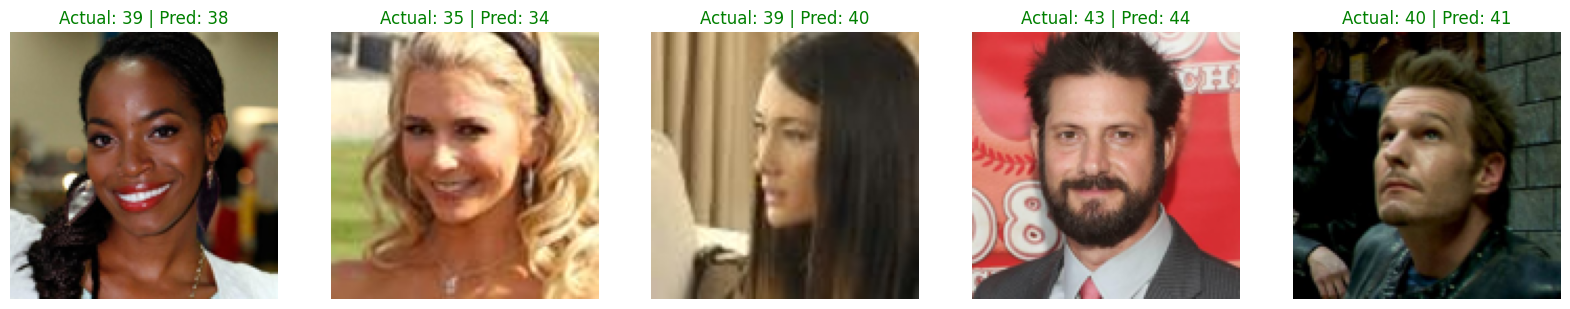

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x_batch, y_batch = next(iter(val_gen))
y_pred_batch = model.predict(x_batch).flatten()

perfect_idxs = [i for i in range(len(x_batch)) if abs(y_batch[i] - y_pred_batch[i]) < 1.5 ]

perfect_idxs = perfect_idxs[:5]

plt.figure(figsize=(20, 10))

for i, idx in enumerate(perfect_idxs):
    img = x_batch[idx]
    true_age = y_batch[idx]
    pred_age = y_pred_batch[idx]

    plt.subplot(2, 5, i+1)
    plt.imshow((img + 1) / 2)
    plt.axis("off")
    plt.title(f"Actual: {int(true_age)} | Pred: {int(pred_age)}", color="green")

plt.show()